## 1. 환경 설정 및 라이브러리 임포트

In [1]:
import os
import sys

# Add the parent directory to Python path to access backbones and solvers
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Current working directory: {os.getcwd()}")
print(f"Added to Python path: {parent_dir}")

Current working directory: d:\logpx\logpx_samplers\examples
Added to Python path: d:\logpx\logpx_samplers


In [2]:
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("🎉 모든 설정이 완벽하게 끝났습니다!")

PyTorch Version: 2.4.0+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 3090
🎉 모든 설정이 완벽하게 끝났습니다!


## 2. 모델 로드

In [3]:
from backbones.dit import DiT

print("Loading DiT model...")
model = DiT()
print("Model loaded successfully!")

d:\conda_envs\logpx_env\lib\site-packages\xformers\ops\fmha\flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
d:\conda_envs\logpx_env\lib\site-packages\xformers\ops\fmha\flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "d:\conda_envs\logpx_env\lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
ModuleNotFoundError: No module named 'triton'


Loading DiT model...


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\transformer: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Expected types for id2label: (typing.Dict[int, str], <class 'NoneType'>), got typing

Model loaded successfully!


## 3. 솔버 비교 실행

In [4]:
def show_compare(euler_img, dpm_img, unipc_img, ds_img, titles = ['Euler', 'DPM-Solver', 'UniPC', 'DS-Solver']):
    images = [img[0] if isinstance(img, list) else img for img in [euler_img, dpm_img, unipc_img, ds_img]]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes = axes.flatten()
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [5]:
from solvers.euler_solver import Euler_Solver
from solvers.dpm_solver import DPM_Solver
from solvers.unipc_solver import UniPC_Solver
from solvers.diff_solver import DS_Solver, DSTrainer

class_labels = [281] # ImageNet class for 'tabby cat'

model_fn, noise_schedule, latents = model.get_model_fn(
    pos_conds=class_labels,
    guidance_scale=4.0,
    seeds=[42]
)

STEPS = 10
results = {}

In [6]:
print("Running Euler Solver...")
solver = Euler_Solver(model_fn, noise_schedule, algorithm_type='data_prediction')
latent_samples = solver.sample(latents.clone(), steps=STEPS, skip_type='time_uniform')
pixel_samples = model.decode_vae(latent_samples)
results['euler'] = pixel_samples

Running Euler Solver...


d:\conda_envs\logpx_env\lib\site-packages\diffusers\models\attention_processor.py:3317: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


In [7]:
print("Running DPM-Solver...")
solver = DPM_Solver(model_fn, noise_schedule, algorithm_type='data_prediction')
latent_samples = solver.sample(latents.clone(), steps=STEPS, order=2, skip_type="time_uniform", method="multistep")
pixel_samples = model.decode_vae(latent_samples)
results['dpm'] = pixel_samples

Running DPM-Solver...


In [8]:
print("Running UniPC Solver...")
solver = UniPC_Solver(model_fn, noise_schedule, algorithm_type='data_prediction')
latent_samples = solver.sample(latents.clone(), steps=STEPS, order=2, skip_type="time_uniform", method="multistep")
pixel_samples = model.decode_vae(latent_samples)
results['unipc'] = pixel_samples

Running UniPC Solver...


In [ ]:
# ================================
# DS-Solver (Differentiable Solver) 검색 + 추론 셀
# ================================
import os
import sys
import time
import torch

# (선택) TQDM 출력 켜기
os.environ["TQDM_DISABLE"] = "false"

# 리포 루트 경로 추가 (노트북이 scripts/notebooks 아래에 있을 때 권장)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# 백본/솔버 임포트
from backbones.dit import DiT
from solvers.diff_solver import DS_Solver, DSTrainer

# --------------------------------
# 설정값
# --------------------------------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE_STR = 'bf16'              # 'bf16' 권장, 필요시 'fp16'
AMP_DTYPE = DTYPE_STR
USE_AMP = False                  # AMP 사용
STEPS = 10                      # 목표 NFE
REFERENCE_STEPS = 10           # 논문 기준(비용 큼). 워밍업은 80~120 권장
NUM_SAMPLES = 50_000            # 검색 샘플 수
BATCH_SIZE = 1000
LR = 1e-2                       # 필요시 3e-3로 낮추면 더 안정적
WEIGHT_DECAY = 0.0
LEARNED_PARAMS_PATH = "optimal_solver_params.pkl"
FORCE_TRAINING = True          # True면 덮어쓰기 재학습

# 클래스 라벨(예: ImageNet 'tabby cat' = 281)
class_labels = [281]

# --------------------------------
# 모델 로드
# --------------------------------
print("Loading DiT backbone...")
model = DiT(device=DEVICE, dtype=(torch.bfloat16 if DTYPE_STR=='bf16' else torch.float16))
print("Model ready.")

# --------------------------------
# (1) 검색(학습)
# --------------------------------
need_train = FORCE_TRAINING or (not os.path.exists(LEARNED_PARAMS_PATH))

if need_train:
    if FORCE_TRAINING and os.path.exists(LEARNED_PARAMS_PATH):
        print(f"[Info] FORCE_TRAINING=True → '{LEARNED_PARAMS_PATH}' 덮어쓰고 재학습합니다.")
    else:
        print(f"[Info] '{LEARNED_PARAMS_PATH}' 없음 → 검색(학습) 시작합니다.")
    print(f"Search config: steps={STEPS}, ref_steps={REFERENCE_STEPS}, nsamples={NUM_SAMPLES}, batch={BATCH_SIZE}, lr={LR}, amp={USE_AMP}/{AMP_DTYPE}")

    trainer = DSTrainer(
        model=model,
        algorithm_type="data_prediction",  # DiT(DDPM) → data_prediction 권장
        target_steps=STEPS,
        reference_steps=REFERENCE_STEPS,
        use_amp=USE_AMP,
        amp_dtype=AMP_DTYPE,
        debug=False,
    )

    t0 = time.time()
    trainer.train(
        num_samples=NUM_SAMPLES,
        batch_size=BATCH_SIZE,
        save_path=LEARNED_PARAMS_PATH,
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )
    print(f"[Search done] elapsed={(time.time()-t0)/60:.1f} min")
else:
    print(f"[Info] 학습된 파라미터 발견: '{LEARNED_PARAMS_PATH}' → 학습 생략")

# --------------------------------
# (2) 추론
# --------------------------------
print("\n--- Preparing for DS-Solver Inference ---")
# 추론은 원하는 CFG로 새 model_fn을 준비
inference_model_fn, noise_schedule, latents = model.get_model_fn(
    pos_conds=class_labels,
    guidance_scale=4.0,              # 원하는 CFG
    seeds=[42],                      # 재현성
)

# 학습된 파라미터로 DS_Solver 초기화
ds_solver = DS_Solver(
    model_fn=inference_model_fn,
    noise_schedule=noise_schedule,
    algorithm_type="data_prediction",
    learned_params_path=LEARNED_PARAMS_PATH,
    steps=STEPS,
    use_amp_sample=USE_AMP,
    amp_dtype=AMP_DTYPE,
)

# 학습된 타임스텝 로그
ds_solver.print_learned_params()

# 샘플링
print("\nRunning DS-Solver inference...")
t0 = time.time()
latent_samples = ds_solver.sample(latents.clone(), steps=STEPS)
elapsed = time.time() - t0
print(f"[DS-Solver] Sampling done in {elapsed:.2f} s")

# VAE 디코딩
pixel_samples = model.decode_vae(latent_samples)

# 결과 보관(기존 results 딕셔너리가 없으면 생성)
try:
    results
except NameError:
    results = {}
results['ds'] = pixel_samples

Loading DiT backbone...


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\transformer: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\hhh\.cache\huggingface\hub\models--facebook--DiT-XL-2-256\snapshots\eab87f77abd5aef071a632f08807fbaab0b704d0\transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Expected types for id2label: (typing.Dict[int, str], <class 'NoneType'>), got typing

Model ready.
[Info] 'optimal_solver_params.pkl' 없음 → 검색(학습) 시작합니다.
Search config: steps=10, ref_steps=10, nsamples=50000, batch=250, lr=0.01, amp=False/bf16
DSTrainer: Using Lion optimizer with lr=0.01 to train BOTH r_params and c_matrix.


Training DS-Solver:   0%|          | 1/200 [00:21<1:12:10, 21.76s/it, loss=0.0158]


Displaying results from all solvers:


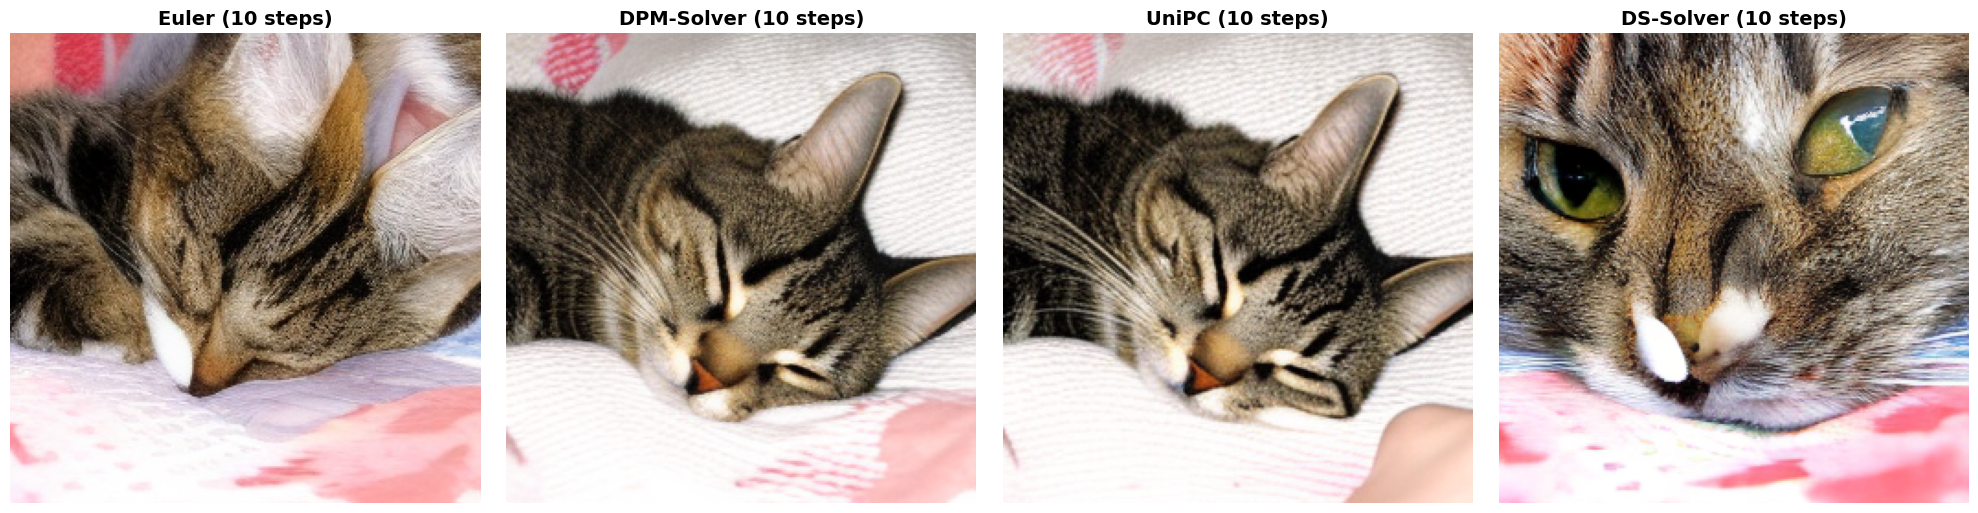

In [ ]:
print("\nDisplaying results from all solvers:")
titles = ['Euler (10 steps)', 'DPM-Solver (10 steps)', 'UniPC (10 steps)', 'DS-Solver (10 steps)']
show_compare(
    results['euler'], 
    results['dpm'], 
    results['unipc'], 
    results['ds'],
    titles=titles
)